# The Constrained / Unconstrained Domains & Getting Likelihoods from MCMC

https://hughmcdougall.github.io/blog/02_numpyro/02_constraineddomain/page.html

JAX's autodiff to calculate gradients -> problem when the distribution/prior has discontinuities (no gradients).

For these cases, numpyro transforms from coordinate that has discontinuities to a continuous one.

But numpyro's features want arguments specified in this unconstrained domain.

This example: transform parameters between the constrained and unconstrained domain.

In [3]:
import jax
import numpyro
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chainconsumer
from chainconsumer import ChainConsumer, Chain

## Transforming between constrained and unconstrained domains

Example: $x \sim \mathcal{U}(0, 2)$, has sharp discontinuities at the edges of this prior.

Make sure we have the `transform_fn` function, engine for changing parameters between domains.

In [4]:
from numpyro.infer.util import transform_fn

dist = numpyro.distributions.Uniform(0, 2)

def model_test():
    x = numpyro.sample('x', dist)

To transform from "constrained" domain (real values) to the "unconstrained" domain, first we generate a range of real 'x' values. Then:
1. Tell numpyro what distributions we have in the dictionary `transforms`.
2. Apply with `transform_fn`: specify which values we're transforming (as second argument), and that we want the unconstrained domain by setting `invert=True`. This returns a dictionary with similar keys.

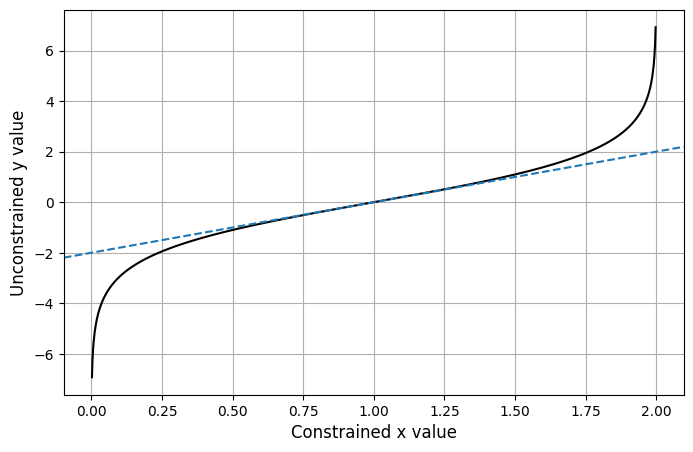

In [13]:
transforms = {
    'x': numpyro.distributions.biject_to(dist.support)
}

x_con = np.linspace(0, 2, 1024)
x_uncon = transform_fn(transforms, {'x': x_con}, invert=True)['x']

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_con, x_uncon, c='k')
plt.axline([1,0], slope=2, c='C0', ls='--')
plt.xlabel("Constrained x value", fontsize=12)
plt.ylabel("Unconstrained y value", fontsize=12)
plt.grid()
plt.show()

1. The transformed values are unconstrained, i.e. $x_\mathrm{uncon} \in (-\infty, \infty)$.
2. They are also 'normalised', i.e. the central value of the constrained domain, $x_\mathrm{con} = 1$, gets transformed to $x_\mathrm{uncon} = 0$.

Next, we transform the likelihood function to this unconstrained domain.
$$P(x_\mathrm{con}) dx_\mathrm{con} = P(_\mathrm{uncon}) dx_\mathrm{uncon}$$
$$P(x_\mathrm{con}) = P(x_\mathrm{uncon}) \cdot \frac{dx_\mathrm{uncon}}{dx_\mathrm{con}}$$

In general, we multiply with the determinant of the Jacobian. As crude approximation, we just use finite differences.

In [29]:
diff = (x_uncon[2:] - x_uncon[:-2]) / (x_con[2:] - x_con[:-2])

Next, feed the unconstrained parameters into the likelihood function, from the `potential_energy` utility function that NumPyro provides. This returns the **negative log likelihood**.

For our model `model_test()`, this looks like:
$$PE(x_\mathrm{uncon}) = -\ln|\mathcal{L}(x_\mathrm{uncon})| = \texttt{numpyro.infer.util.potential\_energy(model\_test, model\_args=(), model\_kwargs=\{\}, params=\{'x': x\})}$$

Even though we have no model `args` or `kwargs`, they still need to be explicitly given as empty tuple or dictionary.

Next, we evaluate our likelihoods in the unconstrained domain, and then correct them back to the constrained domain using the Jacobian.

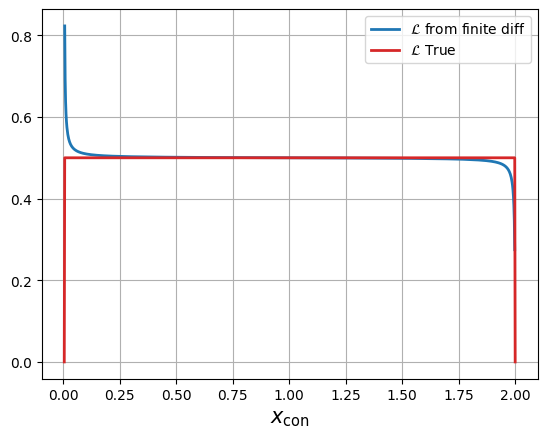

In [30]:
# Get potential energies
PE = [numpyro.infer.util.potential_energy(model_test, model_args=(), model_kwargs={}, params={'x': x}) for x in x_uncon]
PE = np.array(PE)

# Convert to likelihood
L = np.exp(-PE)

# Transform back to constrained domain
y = L[2:] * diff

# True model (for comparison)
y_true = 0.5 * (x_con[2:] > 0.0) * (x_con[2:] < 2.0)
y_true[0] = 0
y_true[-1] = 0

# Plot
plt.plot(x_con[2:], y, c='C0', lw=2, label=r'$\mathcal{L}$ from finite diff')
plt.plot(x_con[2:], y_true, c='C3', lw=2, label=r'$\mathcal{L}$ True')

plt.legend()
plt.xlabel(r'$x_\mathrm{con}$', fontsize=15)
plt.grid()
plt.show()

The poor results at the edges are due to the poor estimates of $\frac{dx_\mathrm{uncon}}{dx_\mathrm{con}}$.

We can use JAX's auto-differentiation to get an analytically accurate derivative function, `jax.grad(function)`.

In [ ]:
def tform(x):
    out = transform_fn(transforms, {'x': x}, invert=True)['x']
    return out

tform_diff = jax.grad(tform)

# Bring everything together in a single function
def l_uncon(x):
    xdash = tform(x)
    diff = tform_diff(x)

    # Calculate the likelihood for the unconstrained
    ll = numpyro.infer.util.potential_energy(model_test, model_args=(), model_kwargs={}, params={'x': xdash})

    # Revert back to constrained
    out = jnp.exp(-ll) * diff

    return out

# Vectorize using JAX
l_uncon = jax.vmap(l_uncon)

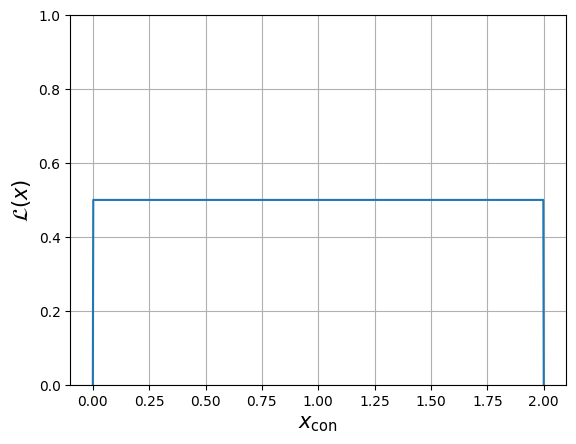

In [40]:
# Evaluate and set any nan values to zero
y = l_uncon(jnp.array(x_con))

y = jnp.nan_to_num(y, copy=False, nan=0.0)

# Plot
plt.plot(x_con, y)
plt.ylim(0, 2 * np.max(y))
plt.xlabel(r'$x_\mathrm{con}$', fontsize=15)
plt.ylabel(r'$\mathcal{L}(x)$', fontsize=15)
plt.grid()
plt.show()

Why do we care about these domains? --> running multiple MCMC chains and retrieving sample likelihoods from an MCMC chain.

## Using domain transforms to get MCMC sample likelihood

Tackle two problems:
1. How to get NumPyro MCMC sampler to record information about the likelihood of the MCMC samples.
2. How to use the information from the constrained/unconstrained domain into a useful value.

Keep things simple: unimodal Gaussian with uniform priors. Instead of using `numpyro.distributions.Normal`, we use `numpyro.factor`, which lets us multiply our posterior by some factor/function.

In [ ]:
# Parameters/prior volume
xmin, xmax = -5, 10
ymin, ymax = -8, 8
V0 = (xmax - xmin) * (ymax - ymin) # prior volume

# Probability function without prior
## This is a bivariate Gaussian with sigma_x = sigma_y = 1, centered at the origin
def prob_func(x, y):
    out = 0
    out += jnp.exp(-0.5 * (x**2 + y**2))
    return out

# Log probability function
def log_prob_func(x, y):
    return jnp.log(prob_func(x, y))

# Numpyro model + prior distribution
distx = numpyro.distributions.Uniform(xmin, xmax)
disty = numpyro.distributions.Uniform(ymin, ymax)

def np_model():
    x = numpyro.sample('x', distx)
    y = numpyro.sample('y', disty)

    numpyro.factor(name='prob_fac', log_factor=log_prob_func(x, y))

Simple distributions -> a single chain should be fine. We can also log the potential energy using `extra_fields` argument.

In [43]:
# Construct the NUTS sampler
MCMC_sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(np_model),
    num_chains=1,
    num_warmup=1000,
    num_samples=50000
)

# Run and store potential energy
MCMC_sampler.run(
    jax.random.PRNGKey(1),
    extra_fields=('potential_energy',),
)
MCMC_results = MCMC_sampler.get_samples()

sample: 100%|██████████| 51000/51000 [00:07<00:00, 7195.37it/s, 3 steps of size 8.17e-01. acc. prob=0.92] 


In HMC, potential energy is proportional to $\chi^2$:
$$U_x(x) = -\ln |\mathcal{L}_x(x)| = -\frac{\chi^2}{2}$$



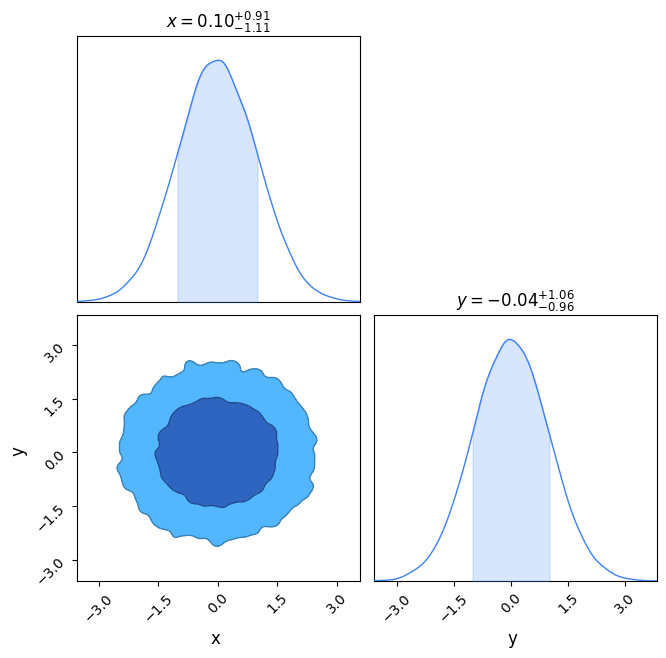

In [46]:
df = pd.DataFrame(MCMC_results)
C = ChainConsumer()
C.add_chain(Chain(samples=df, name="An Example Contour"))
C.plotter.plot(
)

plt.show()

The extra information is accessed through `sampler.get_extra_fields()`.

In [50]:
# Extract potential energy from the sampler
extra_fields = MCMC_sampler.get_extra_fields()
pot_en = extra_fields['potential_energy']

# Get true likelihood for all points for comparison
X, Y = MCMC_results['x'], MCMC_results['y']
Ltrue = np.array([prob_func(x, y) for x, y in zip(X, Y)]) / V0
logLtrue = np.log(Ltrue)

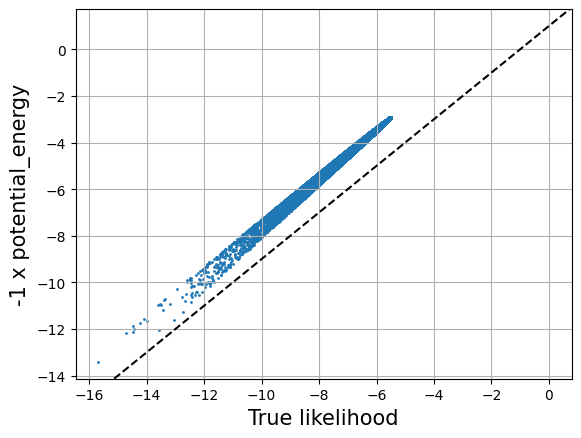

In [55]:
# Compare the sampled PE vs true PE
plt.scatter(logLtrue, -1 * pot_en, s=1)
plt.axline([0, 1], slope=1, c='k', ls='--')
plt.xlabel('True likelihood', fontsize=15)
plt.ylabel('-1 x potential_energy', fontsize=15)
plt.grid()
plt.show()

They are not the same because `potential_energy` is defined in unconstrained parameter space. Transform back with
$$U_\theta (\theta) = U_x (x) \cdot D$$

Since x and y are uncorrelated, we can simply multiply the gradients:
$$D = \prod_i \left(\frac{dx'_i}{d\theta_i}\right)$$

To do this,
1. Get transformation functions from $x \leftrightarrow \theta$
2. Take their gradients using `jax.grad`
3. Get a function that takes their product to get the conversion factor

We can apply JAX's function transformations using decorators.

In [58]:
transforms = {
    'x': numpyro.distributions.biject_to(distx.support),
    'y': numpyro.distributions.biject_to(disty.support)
}

@jax.grad
def _tformx(x):
    out1 = transform_fn(transforms, {'x': x}, invert=True)['x']

    return out1

@jax.grad
def _tformy(y):
    out2 = transform_fn(transforms, {'y': y}, invert=True)['y']

    return out2

@jax.vmap
def tform_diff_xy(x, y):
    out = _tformx(x) * _tformy(y)
    return out

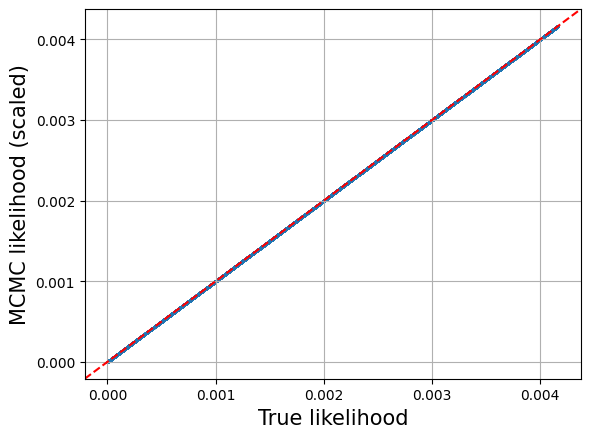

In [68]:
# Calculate the scaling and apply to the likelihood from potential energy
diff_scaling = tform_diff_xy(X, Y)
L_from_MCMC = np.exp(-pot_en) * diff_scaling

# Compare again
plt.axline([0, 0], slope=1, c='r', ls='--')
plt.scatter(Ltrue, L_from_MCMC, s=1)
plt.xlabel('True likelihood', fontsize=15)
plt.ylabel('MCMC likelihood (scaled)', fontsize=15)
plt.grid()
plt.show()


## Specifying MCMC start positions

We'll use `constrain_fn` and `unconstrain_fn` to specify initial conditions for a set of MCMC chains.

Consider a 2D Gaussian posterior in parameters $x$ and $y$, constrained by a uniform prior, $x, y \in [-10, 10]$

Start 4 MCMC chains at 4 different positions:
$$(x_0, y_0) = ([0, 5], [5, 0], [0, -5], [-5, 0])$$

In [71]:
# Create a sampler. Set step_size to be very small to better see the initial movement of the walkers
sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(np_model, step_size=1e-10),
    num_chains=4,
    num_samples=1,
    num_warmup=1000
)

/var/folders/50/_r7c0z0x3bl4zx6npn1b1x480000gn/T/ipykernel_86455/2904157193.py:2: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  sampler = numpyro.infer.MCMC(


In [72]:
# Encode starting positions in a dictionary
init_pos = {
    'x': jnp.array([0, 5, 0, -5]),
    'y': jnp.array([0, 5, 0, -5])
}

# Use unconstrain_fn -> does the same thing as the transform_fn, but automatically reads in all of the information about the prior from the defined model
init_pos_uncon = numpyro.infer.util.unconstrain_fn(
    model=np_model,
    model_args=(),
    model_kwargs={},
    params=init_pos
)

In [73]:
sampler.warmup(
    jax.random.PRNGKey(1),
    init_params=init_pos_uncon,
    collect_warmup=True
)
res = sampler.get_samples()
nchains = sampler.num_chains

warmup: 100%|██████████| 1000/1000 [00:00<00:00, 7495.01it/s, 1 steps of size 1.18e-38. acc. prob=0.00]


In [ ]:
plt.figure(figsize=(8, 5))
label = 'Actual chain start'
for i in range(nchains):
    plt.plot(res['x'][i * nsamples])

{'x': Array([ 5.9604645e-07,  5.9604645e-07,  5.9604645e-07, ...,
        -5.0000000e+00, -5.0000000e+00, -5.0000000e+00], dtype=float32),
 'y': Array([ 0.0000000e+00, -9.5367432e-07, -1.9073486e-06, ...,
        -5.0000000e+00, -5.0000000e+00, -5.0000000e+00], dtype=float32)}

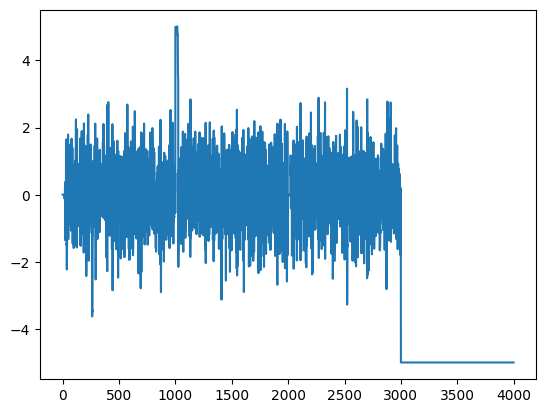

In [80]:
plt.plot(list(range(0, len(res['x']))), res['x'])

In [77]:
res

{'x': Array([ 5.9604645e-07,  5.9604645e-07,  5.9604645e-07, ...,
        -5.0000000e+00, -5.0000000e+00, -5.0000000e+00], dtype=float32),
 'y': Array([ 0.0000000e+00, -9.5367432e-07, -1.9073486e-06, ...,
        -5.0000000e+00, -5.0000000e+00, -5.0000000e+00], dtype=float32)}